In [5]:
import sys
sys.path.append('..')

from IPython.display import Image, display

## Execution Agent Graph

webhook → ReAct 루프.

**노드**

| 노드 | 역할 |
|---|---|
| `agent_node` | LLM이 tool_call 또는 최종 응답 결정 |
| `tool_executor_node` | tool 실행 |
| `block_node` | allowlist 위반 tool_call 차단, LLM에 에러 반환 후 루프 복귀 |

**conditional edge 라우터** (그래프에 노드로 표시되지 않음)

| 라우터 | 출처 노드 | 조건 |
|---|---|---|
| `tool_gate` | `agent_node` | tool_call 없음→END / allowlist 통과→tool_executor / 위반→block |

---

> **[planned]** `tool_executor_node`에 `failure_policy` 집행(SILENT_SKIP / RETRY_THEN_NOTIFY / NOTIFY_AND_STOP) 추가 시 `post_executor_route` conditional edge 도입 예정.
> `stop_reason` 있음→END / 없음→agent_node

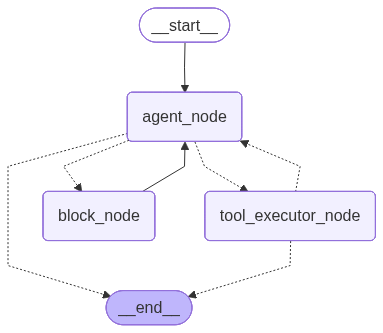

In [6]:
from functools import partial
from typing import Annotated, TypedDict

from langgraph.graph import END, StateGraph
from langgraph.graph.message import add_messages

from catchup.agents.harness.nodes import block_node, tool_gate


class _State(TypedDict):
    messages: Annotated[list, add_messages]
    allowed_tool_names: list[str]
    stop_reason: str | None


async def _noop_agent(state, *, llm_with_tools): return {}
async def _noop_executor(state, *, lc_tool_map, tool_spec_map): return {}


def _post_executor_route(state: _State) -> str:
    return END if state.get("stop_reason") else "agent_node"


g = StateGraph(_State)
g.add_node('agent_node',        partial(_noop_agent,    llm_with_tools=None))
g.add_node('tool_executor_node', partial(_noop_executor, lc_tool_map={}, tool_spec_map={}))
g.add_node('block_node',         block_node)

g.set_entry_point('agent_node')
g.add_conditional_edges(
    'agent_node', tool_gate,
    {'tool_executor_node': 'tool_executor_node', 'block_node': 'block_node', END: END},
)
g.add_conditional_edges(
    'tool_executor_node', _post_executor_route,
    {'agent_node': 'agent_node', END: END},
)
g.add_edge('block_node', 'agent_node')

exec_graph = g.compile()
display(Image(exec_graph.get_graph().draw_mermaid_png()))